In [2]:
from PySpice.Spice.NgSpice.Shared import NgSpiceCommandError
from PySpice.Spice.NgSpice.Simulation import NgSpiceSharedCircuitSimulator


class NgSpice42CircuitSimulator(NgSpiceSharedCircuitSimulator):
    """ngspice 42 のソルバ起動メッセージによる誤判定を回避する。"""

    def _run(self, analysis_method, *args, **kwargs):
        try:
            return super()._run(analysis_method, *args, **kwargs)
        except NgSpiceCommandError:
            messages = self._ngspice_shared._stderr
            is_solver_banner = messages and all(
                message.strip().startswith("Using ")
                and message.strip().endswith("as Direct Linear Solver")
                for message in messages
            )
            if not is_solver_banner:
                raise
            self._ngspice_shared._error_in_stderr = False
            self.reset_analysis()
            return self._ngspice_shared.plot(
                self, self._ngspice_shared.last_plot
            ).to_analysis()

Unsupported Ngspice version 42
Using SPARSE 1.3 as Direct Linear Solver


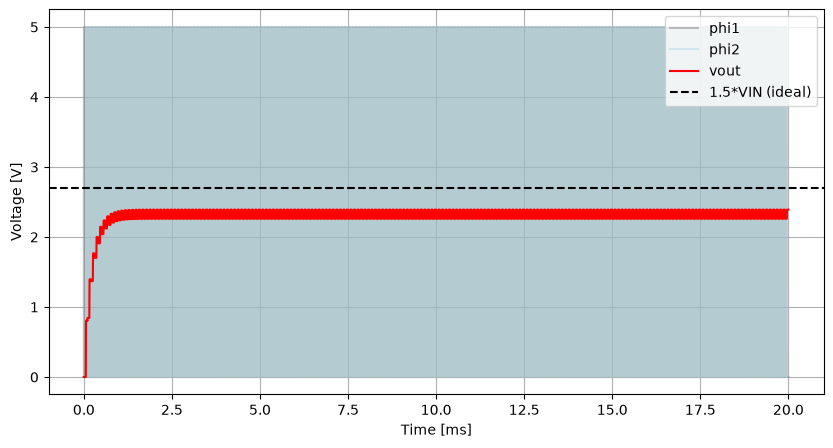

In [3]:
from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import u_V, u_uF, u_kOhm, u_Ohm, u_ns, u_us, u_s, u_kHz
import matplotlib.pyplot as plt

# 電源・クロック条件
VIN = 1.8 @ u_V
FCLK = 10 @ u_kHz
PERIOD = 1 / FCLK
VGATE = 5 @ u_V  # スイッチ駆動用ゲート電圧(理想スイッチのON/OFFしきい値を超える十分な振幅)

circuit = Circuit("1.5x Fractional Charge Pump")

# 入力電源
circuit.V("in", "vin", circuit.gnd, VIN)

# 2相の非重複クロック (phi1, phi2)
# phi1: 直列充電フェーズ, phi2: 並列放電(出力)フェーズ
# デッドタイムを設けて貫通(直列充電と並列出力の状態が重ならないよう)を防ぐ
DEAD = PERIOD * 0.05

circuit.PulseVoltageSource(
    "phi1", "phi1", circuit.gnd,
    initial_value=0 @ u_V,
    pulsed_value=VGATE,
    delay_time=0 @ u_s,
    rise_time=1 @ u_us,
    fall_time=1 @ u_us,
    pulse_width=PERIOD / 2 - DEAD,
    period=PERIOD,
)
circuit.PulseVoltageSource(
    "phi2", "phi2", circuit.gnd,
    initial_value=0 @ u_V,
    pulsed_value=VGATE,
    delay_time=PERIOD / 2 + DEAD,
    rise_time=1 @ u_us,
    fall_time=1 @ u_us,
    pulse_width=PERIOD / 2 - DEAD,
    period=PERIOD,
)

# 理想スイッチモデル(オン抵抗/オフ抵抗、しきい値はVGATEの半分)
circuit.model(
    "SWMOD", "SW",
    VT=float(VGATE) / 2, VH=0.1, RON=1 @ u_Ohm, ROFF=1e9,
)

# ------------------------------------------------------------------
# 1.5x スイッチドキャパシタ・チャージポンプ
#
# フライングキャパシタ Cf1, Cf2 (各容量C)
#
# フェーズ1 (直列充電): Cf1, Cf2 を VIN-GND 間に直列接続して充電
#   vin --S1-- a --Cf1-- b --S2-- c --Cf2-- d --S3-- gnd
#   (定常状態で Va-Vb = Vc-Vd = VIN/2 となるよう充電される)
#
# フェーズ2 (並列放電): Cf1, Cf2 を VIN-VOUT 間に並列接続して出力
#   vin --S4-- b, vin --S5-- d  (Cf1,Cf2の上側をvinへ)
#   a, c --S6-- vout           (Cf1,Cf2の下側をvoutへ束ねる)
#   -> 定常状態で Vout = Vin + VIN/2 = 1.5*Vin
# ------------------------------------------------------------------

circuit.VoltageControlledSwitch("1", "vin", "n_a", "phi1", circuit.gnd, model="SWMOD")
circuit.C("f1", "n_a", "n_b", 1 @ u_uF)
circuit.VoltageControlledSwitch("2", "n_b", "n_c", "phi1", circuit.gnd, model="SWMOD")
circuit.C("f2", "n_c", "n_d", 1 @ u_uF)
circuit.VoltageControlledSwitch("3", "n_d", circuit.gnd, "phi1", circuit.gnd, model="SWMOD")

circuit.VoltageControlledSwitch("4", "vin", "n_b", "phi2", circuit.gnd, model="SWMOD")
circuit.VoltageControlledSwitch("5", "vin", "n_d", "phi2", circuit.gnd, model="SWMOD")
circuit.VoltageControlledSwitch("6", "n_a", "vout", "phi2", circuit.gnd, model="SWMOD")
circuit.VoltageControlledSwitch("7", "n_c", "vout", "phi2", circuit.gnd, model="SWMOD")

# 出力平滑コンデンサと負荷
circuit.C("out", "vout", circuit.gnd, 4.7 @ u_uF)
circuit.R("load", "vout", circuit.gnd, 100 @ u_kOhm)

simulator = NgSpice42CircuitSimulator(
    circuit,
    temperature=25,
    nominal_temperature=25,
)
analysis = simulator.transient(
    step_time=PERIOD / 400,
    end_time=200 * PERIOD,
)

# 波形表示用
time = analysis.time.as_ndarray() * 1e3  # ms
phi1 = analysis["phi1"].as_ndarray()
phi2 = analysis["phi2"].as_ndarray()
vout = analysis["vout"].as_ndarray()

plt.figure(figsize=(10, 5))
plt.plot(time, phi1, label="phi1", color="gray", alpha=0.5)
plt.plot(time, phi2, label="phi2", color="lightblue", alpha=0.5)
plt.plot(time, vout, label="vout", color="red")
plt.axhline(1.5 * float(VIN), color="black", linestyle="--", label="1.5*VIN (ideal)")
plt.xlabel("Time [ms]")
plt.ylabel("Voltage [V]")
plt.legend()
plt.grid(True)
plt.show()

In [4]:
import numpy as np

vout_final = float(analysis["vout"][-1])
vout_ideal = 1.5 * float(VIN)

# 定常状態(最後の10周期)での平均値・リップルを評価
steady_state = time > (time[-1] - 10 * float(PERIOD * 1e3))
vout_steady = vout[steady_state]

print(f"理想的な1.5倍出力: 1.5*VIN                 = {vout_ideal:.3f} V")
print(f"シミュレーションによる出力電圧(終端)        = {vout_final:.3f} V")
print(f"定常状態の平均出力電圧                      = {vout_steady.mean():.3f} V")
print(f"定常状態のリップル(Vpp)                     = {vout_steady.max() - vout_steady.min():.4f} V")
print(f"効率(実測/理想)                             = {vout_steady.mean() / vout_ideal * 100:.1f} %")
print()
print("理想値との差は主に (1) スイッチのオン抵抗(RON=1ohm)によるIRドロップ,")
print("(2) クロック周波数(10kHz)とフライング容量(1uF)に対して負荷電流が")
print("大きく、1周期あたりの電荷転送量が負荷消費に対して不足気味であること,")
print("に起因する。FCLKを上げる、またはCf1/Cf2を大きくすることで")
print("理想値に近づけられる。")

理想的な1.5倍出力: 1.5*VIN                 = 2.700 V
シミュレーションによる出力電圧(終端)        = 2.391 V
定常状態の平均出力電圧                      = 2.315 V
定常状態のリップル(Vpp)                     = 0.1313 V
効率(実測/理想)                             = 85.7 %

理想値との差は主に (1) スイッチのオン抵抗(RON=1ohm)によるIRドロップ,
(2) クロック周波数(10kHz)とフライング容量(1uF)に対して負荷電流が
大きく、1周期あたりの電荷転送量が負荷消費に対して不足気味であること,
に起因する。FCLKを上げる、またはCf1/Cf2を大きくすることで
理想値に近づけられる。


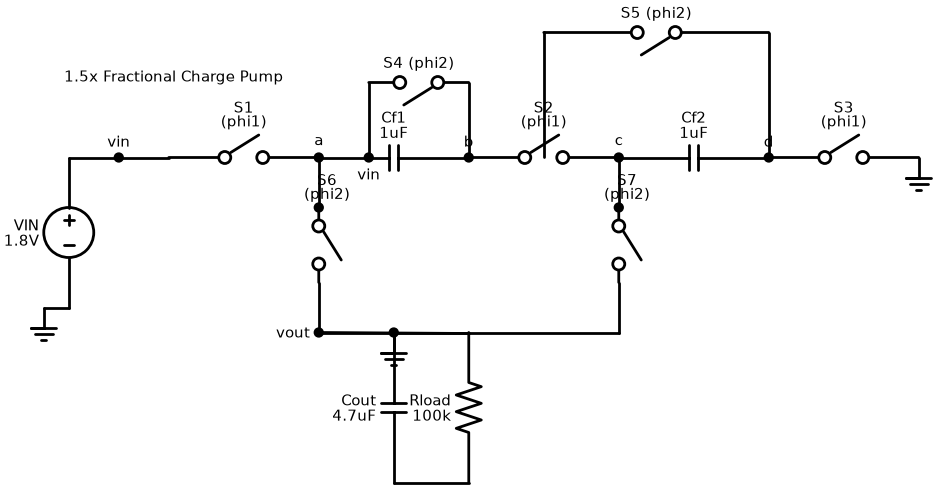

In [5]:
import schemdraw
import schemdraw.elements as elm

with schemdraw.Drawing() as d:
    d.config(fontsize=11)
    d += elm.Label().label("1.5x Fractional Charge Pump").at((2, 4.5))

    # VIN 電源
    d += (Vin := elm.SourceV().up().label("VIN\n1.8V"))
    d += elm.Line().right().length(1.0)
    d += elm.Dot().label("vin", loc="top")

    # フェーズ1(直列充電)経路: vin -S1- a -Cf1- b -S2- c -Cf2- d -S3- gnd
    d += elm.Line().right().length(1.0)
    d += (S1 := elm.Switch().right().label("S1\n(phi1)", loc="top"))
    node_a = S1.end
    d += elm.Dot().at(node_a).label("a", loc="top")
    d += elm.Capacitor().right().at(node_a).label("Cf1\n1uF")
    node_b = d.here
    d += elm.Dot().label("b", loc="top")
    d += (S2 := elm.Switch().right().label("S2\n(phi1)", loc="top"))
    node_c = S2.end
    d += elm.Dot().at(node_c).label("c", loc="top")
    d += elm.Capacitor().right().at(node_c).label("Cf2\n1uF")
    node_d = d.here
    d += elm.Dot().label("d", loc="top")
    d += (S3 := elm.Switch().right().label("S3\n(phi1)", loc="top"))
    d += elm.Ground()

    # フェーズ2(並列放電)経路: vin -S4- b, vin -S5- d (Cf1/Cf2の上側をvinへ)
    d += elm.Line().at(node_b).up().length(1.5)
    d += (S4 := elm.Switch().left().length(2.0).label("S4 (phi2)", loc="top"))
    d += elm.Line().down().length(1.5)
    d += elm.Dot().label("vin", loc="bottom")

    d += elm.Line().at(node_d).up().length(2.5)
    d += (S5 := elm.Switch().left().length(4.5).label("S5 (phi2)", loc="top"))
    d += elm.Line().down().length(2.5)

    # a, c を vout バスへ束ねる (Cf1/Cf2の下側をvoutへ)
    d += elm.Line().at(node_a).down().length(1.0)
    d += elm.Dot()
    d += (S6 := elm.Switch().down().length(1.5).label("S6\n(phi2)", loc="right"))
    d += elm.Line().down().length(1.0)
    d += elm.Dot().label("vout", loc="left")
    node_vout = d.here

    d += elm.Line().at(node_c).down().length(1.0)
    d += elm.Dot()
    d += (S7 := elm.Switch().down().length(1.5).label("S7\n(phi2)", loc="right"))
    d += elm.Line().down().length(1.0)
    d += elm.Line().left().tox(node_vout)

    # Cout + Rload
    d += elm.Line().at(node_vout).right().length(1.5)
    d += elm.Dot()
    d += elm.Capacitor().down().label("Cout\n4.7uF")
    d += elm.Line().right().length(1.5)
    d += elm.Resistor().up().label("Rload\n100k")
    d += elm.Line().left().length(1.5)
    d += elm.Ground()

    # VIN の接地
    d.here = Vin.start
    d += elm.Line().left().length(0.5)
    d += elm.Ground()

    d.draw()